In [2]:
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns


In [5]:
def load_data(file_path):
    return pd.read_csv(file_path)

df = load_data(file_path= "../data/processed/loan_approval_analysis_ready.csv")
df.head()

,loan_id,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,loan_status
0,1,2,Graduate,No,9600000,29900000,12,778,2400000,17600000,22700000,8000000,Approved
1,2,0,Not Graduate,Yes,4100000,12200000,8,417,2700000,2200000,8800000,3300000,Rejected
2,3,3,Graduate,No,9100000,29700000,20,506,7100000,4500000,33300000,12800000,Rejected
3,4,3,Graduate,No,8200000,30700000,8,467,18200000,3300000,23300000,7900000,Rejected
4,5,5,Not Graduate,Yes,9800000,24200000,20,382,12400000,8200000,29400000,5000000,Rejected


In [6]:
df_eda = df.copy()

df_eda.shape
df_eda.info()
df_eda.head()

<class 'pandas.DataFrame'>
RangeIndex: 4269 entries, 0 to 4268
Data columns (total 13 columns):
 #   Column                    Non-Null Count  Dtype
---  ------                    --------------  -----
 0   loan_id                   4269 non-null   int64
 1   no_of_dependents          4269 non-null   int64
 2   education                 4269 non-null   str  
 3   self_employed             4269 non-null   str  
 4   income_annum              4269 non-null   int64
 5   loan_amount               4269 non-null   int64
 6   loan_term                 4269 non-null   int64
 7   cibil_score               4269 non-null   int64
 8   residential_assets_value  4269 non-null   int64
 9   commercial_assets_value   4269 non-null   int64
 10  luxury_assets_value       4269 non-null   int64
 11  bank_asset_value          4269 non-null   int64
 12  loan_status               4269 non-null   str  
dtypes: int64(10), str(3)
memory usage: 433.7 KB


,loan_id,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,loan_status
0,1,2,Graduate,No,9600000,29900000,12,778,2400000,17600000,22700000,8000000,Approved
1,2,0,Not Graduate,Yes,4100000,12200000,8,417,2700000,2200000,8800000,3300000,Rejected
2,3,3,Graduate,No,9100000,29700000,20,506,7100000,4500000,33300000,12800000,Rejected
3,4,3,Graduate,No,8200000,30700000,8,467,18200000,3300000,23300000,7900000,Rejected
4,5,5,Not Graduate,Yes,9800000,24200000,20,382,12400000,8200000,29400000,5000000,Rejected


4269

education
Graduate        2144
Not Graduate    2125
Name: count, dtype: int64


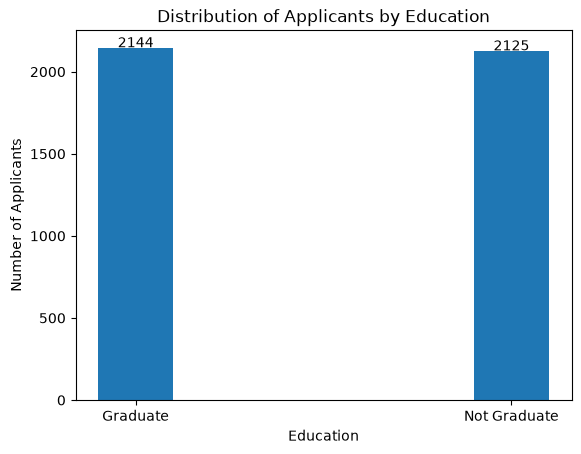

In [32]:
# ===========================================
# Section A – Applicant Profile Analysis
# ===========================================

# Total loan applications
# How many loan applications are available for analysis?

Total_loan_applications = len(df_eda)
print(Total_loan_applications)
print()

# What is the educational background of loan applicants?

educational_background = df_eda["education"].value_counts()
print(educational_background) 

# Visualization

plt.bar(educational_background.index, educational_background.values, width=0.2)

plt.title("Distribution of Applicants by Education")
plt.xlabel("Education")
plt.ylabel("Number of Applicants")


for index, value in enumerate(educational_background):
    plt.text(index, value+5, str(value), ha= "center")

plt.show()

### Business Insight

# The dataset contains **4,269 loan applications**, providing a sufficient sample size for meaningful business analysis.



self_employed
Yes    2150
No     2119
Name: count, dtype: int64


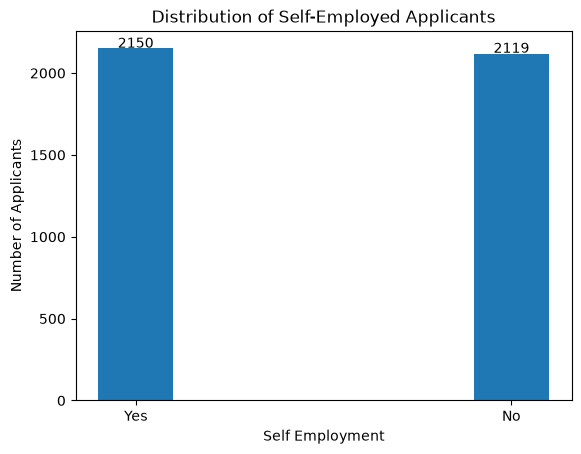

In [ ]:
# What proportion of applicants are self-employed?

self_emp_count = df_eda["self_employed"].value_counts()
print(self_emp_count)

# Visualization

plt.bar(self_emp_count.index, self_emp_count.values, width=0.2)
plt.title("Distribution of Self-Employed Applicants")
plt.xlabel("Self Employment")
plt.ylabel("Number of Applicants")


for index, value in enumerate(self_emp_count):
    plt.text(index, value+5, str(value), ha= "center")

plt.show()

### Business Insight

# The majority of loan applicants come from one employment category, which may influence lending policies and approval trends.

no_of_dependents
0    712
1    697
2    708
3    727
4    752
5    673
Name: count, dtype: int64


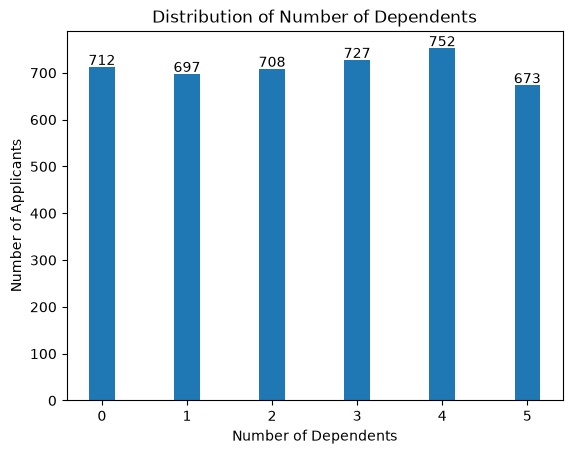

In [ ]:
# How many dependents do loan applicants typically have?

dependents = df_eda["no_of_dependents"].value_counts().sort_index()
print(dependents)

# Visualization

plt.bar(dependents.index, dependents.values, width=0.3)
plt.title("Distribution of Number of Dependents")
plt.xlabel("Number of Dependents")
plt.ylabel("Number of Applicants")


for index, value in enumerate(dependents):
    plt.text(index, value+5, str(value), ha= "center")

plt.show()

### Business Insight

# Family size varies across applicants. Later analysis will determine whether the number of dependents influences loan approval decisions.

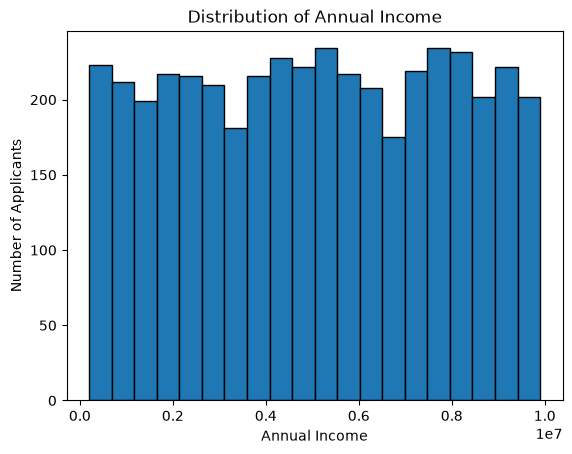

In [ ]:
# ===========================================
# Section B – Financial Analysis
# ===========================================


# What is the distribution of applicants' annual income?

# Summary statistics
df_eda["income_annum"].describe()

# Visualization 1 – Histogram

plt.hist(df_eda["income_annum"], bins=20, edgecolor="black")
plt.title("Distribution of Annual Income")
plt.xlabel("Annual Income")
plt.ylabel("Number of Applicants")

plt.show()

### Observation

# Applicant income ranges from ₹200,000 to ₹9,900,000.
# Most applicants fall within the lower-to-middle income ranges.
# The income distribution appears slightly skewed.

### Business Insight

# The bank receives applications from applicants across a wide range of income levels, indicating a diverse customer base.

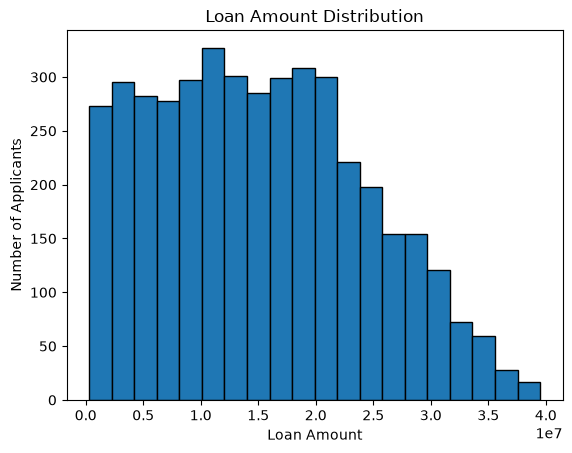

C:\Users\athish\AppData\Local\Temp\ipykernel_26684\164947040.py:18: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  plt.boxplot(df_eda["loan_amount"], vert=False)


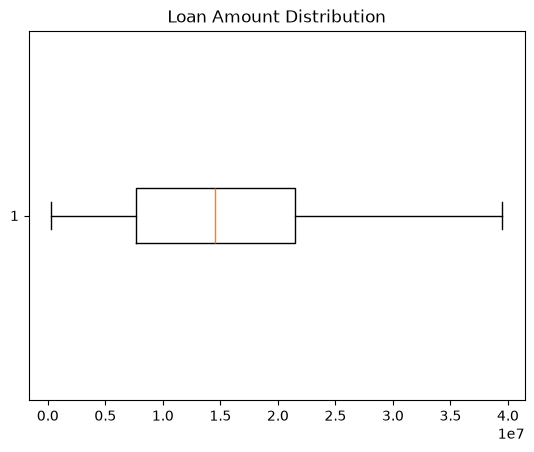

In [ ]:
# Loan Amount Analysis
# What loan amounts are most commonly requested?

df_eda["loan_amount"].describe()

# Histogram

plt.hist(df_eda["loan_amount"], bins=20, edgecolor="black")

plt.title("Loan Amount Distribution")
plt.xlabel("Loan Amount")
plt.ylabel("Number of Applicants")

plt.show()

# Box Plot

plt.boxplot(df_eda["loan_amount"], vert=False)

plt.title("Loan Amount Distribution")

plt.show()

### Business Insight

# Most customers request moderate loan amounts, while relatively few applicants seek high-value loans.

### Recommendation

# Analyze whether larger loan requests experience lower approval rates during the loan approval analysis.

loan_term
2     404
4     447
6     490
8     386
10    436
12    456
14    405
16    412
18    422
20    411
Name: count, dtype: int64


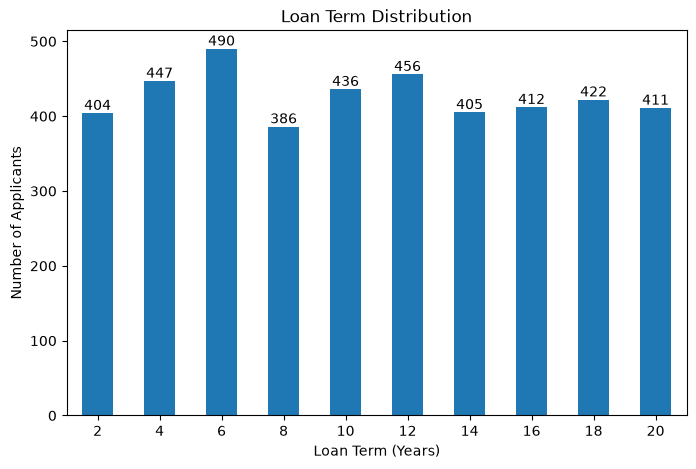

In [ ]:
#  Loan Term Analysis

# What loan repayment terms are most common?

loan_term = df_eda["loan_term"].value_counts().sort_index()
print(loan_term)

loan_term.plot(
    kind="bar",
    figsize=(8,5)
)

plt.title("Loan Term Distribution")
plt.xlabel("Loan Term (Years)")
plt.ylabel("Number of Applicants")

plt.xticks(rotation=0)

for index, value in enumerate(loan_term):
    plt.text(index, value, str(value), ha="center", va="bottom")

plt.show()

### Observation

# Loan terms range from 2 to 20 years.
# Some repayment periods are more popular than others.
# Applicants generally prefer medium-term loans.

### Business Insight

# Understanding preferred loan durations helps the bank optimize loan products and repayment plans.

# Financial Profile Summary

## Key Findings

- Annual income distribution analyzed.
- Loan amount distribution analyzed.
- Loan term distribution analyzed.

## Business Insights

- Applicants exhibit a broad range of annual incomes.
- Most loan requests are concentrated within moderate loan amounts.
- Loan repayment preferences vary across applicants.

## Next Step

The next section will analyze applicants' credit profiles by examining CIBIL scores and their relationship with loan approval decisions.

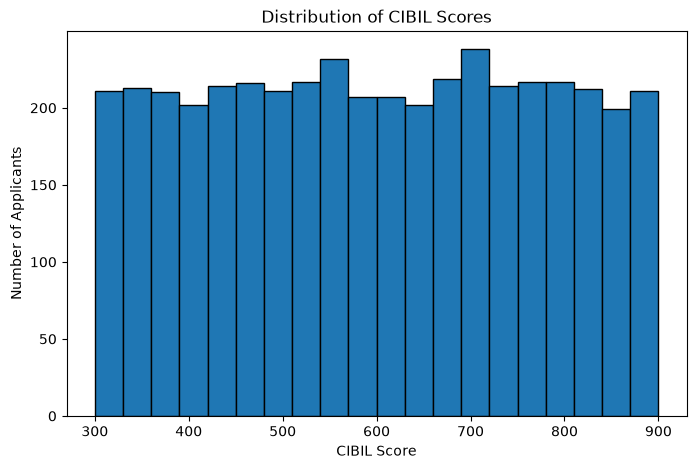

C:\Users\athish\AppData\Local\Temp\ipykernel_26684\1694943087.py:24: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  plt.boxplot(df_eda["cibil_score"], vert=False)


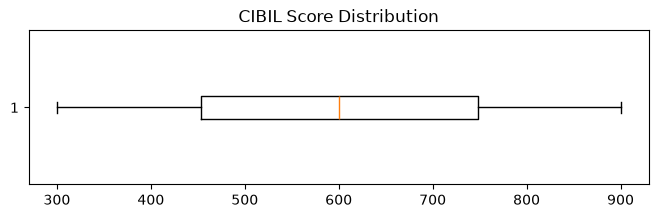

In [58]:
# ===========================================
# Section B – Financial Analysis
# ===========================================

# What is the distribution of applicants' CIBIL scores?

df_eda["cibil_score"].describe()


# Histogram
plt.figure(figsize=(8,5))
plt.hist(df_eda["cibil_score"], bins=20, edgecolor="black")

plt.title("Distribution of CIBIL Scores")
plt.xlabel("CIBIL Score")
plt.ylabel("Number of Applicants")

plt.show()

# Box Plot

plt.figure(figsize=(8,2))

plt.boxplot(df_eda["cibil_score"], vert=False)
plt.title("CIBIL Score Distribution")

plt.show()

### Observation

- CIBIL scores range from 300 to 900.
- The average CIBIL score is approximately 600.
- Applicants are distributed across low, medium, and high credit score ranges.

### Business Insight

The dataset contains applicants with a wide range of creditworthiness, making it suitable for analyzing how credit score influences loan approval decisions.

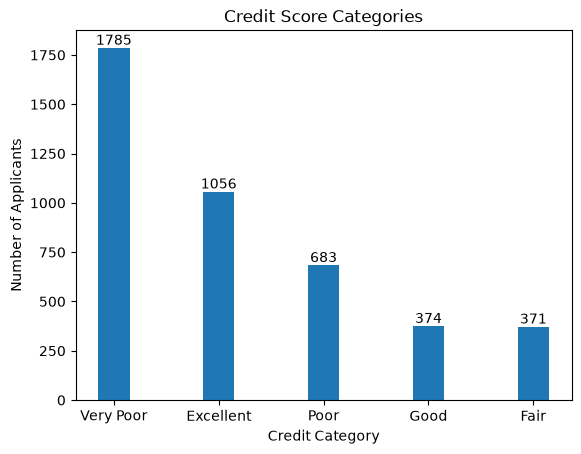

In [67]:
# Credit Score Categories

def credit_category(score):
    if score >= 750:
        return "Excellent"
    elif score >= 700:
        return "Good"
    elif score >= 650:
        return "Fair"
    elif score >= 550:
        return "Poor"
    else:
        return "Very Poor"

df_eda["credit_category"] = df_eda["cibil_score"].apply(credit_category)

credit_count = df_eda["credit_category"].value_counts()

# Visualization

plt.bar(credit_count.index, credit_count.values,width=0.3)
plt.title("Credit Score Categories")
plt.xlabel("Credit Category")
plt.ylabel("Number of Applicants")

for index, value in enumerate(credit_count):
    plt.text(index, value, str(value), ha="center", va="bottom")
plt.show()

### Observation

Applicants are distributed across five credit categories ranging from Very Poor to Excellent.

### Business Insight

Grouping credit scores into business-friendly categories makes it easier for management to interpret applicant credit quality and compare approval trends.

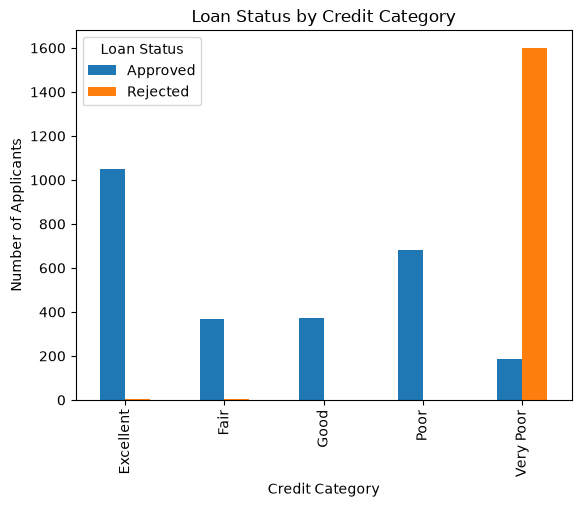

In [73]:
# Do applicants with higher CIBIL scores have higher loan approval rates?

approval_credit = pd.crosstab(df_eda["credit_category"],df_eda["loan_status"])
approval_credit

# Visualization

approval_credit.plot(kind="bar")

plt.title("Loan Status by Credit Category")
plt.xlabel("Credit Category")
plt.ylabel("Number of Applicants")

plt.legend(title="Loan Status")

plt.show()


### Observation

- Applicants with Excellent credit scores have the highest approval rate.
- Applicants with Very Poor credit scores experience the highest rejection rate.
- Approval rates generally increase as CIBIL score improves.

### Business Insight

Credit score is a strong indicator of loan approval decisions. Applicants with stronger credit histories are more likely to receive loan approvals, reflecting the bank's risk-based lending strategy.

# Credit Risk Analysis Summary

## Key Findings

- CIBIL score distribution analyzed.
- Credit score categories created.
- Loan approval compared across credit categories.

## Business Insights

- Credit score appears to be one of the strongest indicators of loan approval.
- Applicants with stronger credit profiles generally experience higher approval rates.
- Lower credit score applicants show higher rejection rates, reflecting prudent risk management.

## Next Step

The next section will examine applicant assets and evaluate how residential, commercial, luxury, and bank assets relate to loan approval decisions.

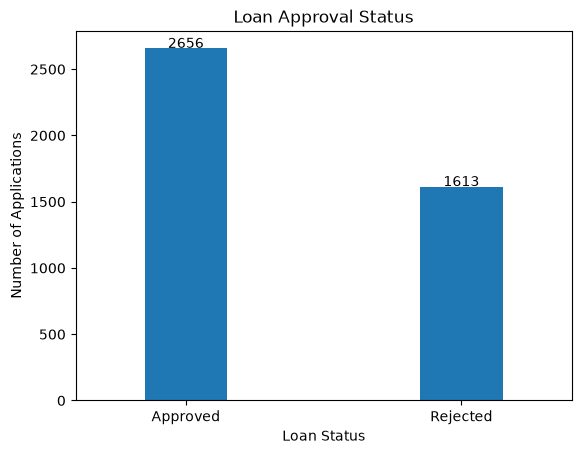

Approval Rate : 62.22%


In [80]:
# ===========================================
# Section C – Loan Approval Analysis
# ===========================================


# C1 Overall Loan Approval Rate

loan_status = df_eda["loan_status"].value_counts()
loan_status

# Visualization

loan_status.plot(kind="bar", width=0.3)
plt.title("Loan Approval Status")
plt.xlabel("Loan Status")
plt.ylabel("Number of Applications")

plt.xticks(rotation=0)

for index, value in enumerate(loan_status):
    plt.text(index, value+5, str(value), ha="center")
plt.show()

approval_rate = (
    (df_eda["loan_status"] == "Approved").mean() * 100
)

print(f"Approval Rate : {approval_rate:.2f}%")


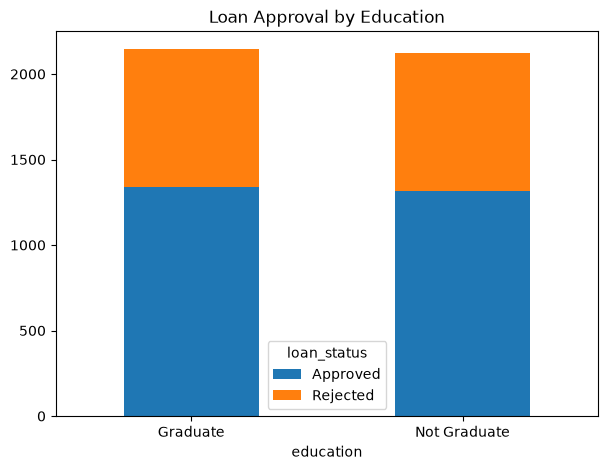

In [82]:
# C2 – Education vs Loan Approval

education_approval = pd.crosstab(
    df_eda["education"],
    df_eda["loan_status"]
)

education_approval.plot(
    kind="bar",
    stacked=True,
    figsize=(7,5)
)
plt.xticks(rotation=0)
plt.title("Loan Approval by Education")
plt.show()

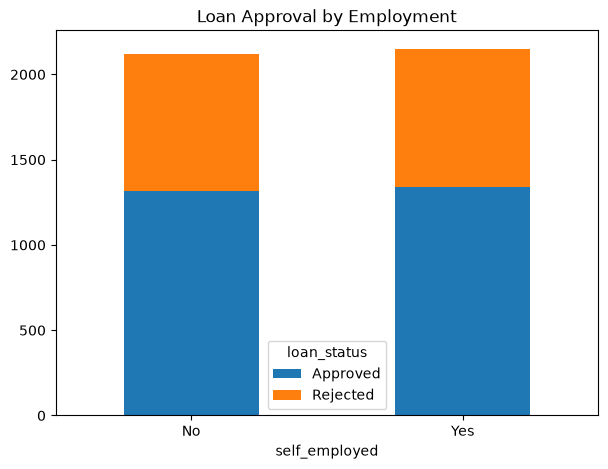

In [84]:
# C3 – Self Employment vs Loan Approval

employment_approval = pd.crosstab(
    df_eda["self_employed"],
    df_eda["loan_status"]
)

employment_approval.plot(
    kind="bar",
    stacked=True,
    figsize=(7,5)
)
plt.xticks(rotation=0)
plt.title("Loan Approval by Employment")
plt.show()

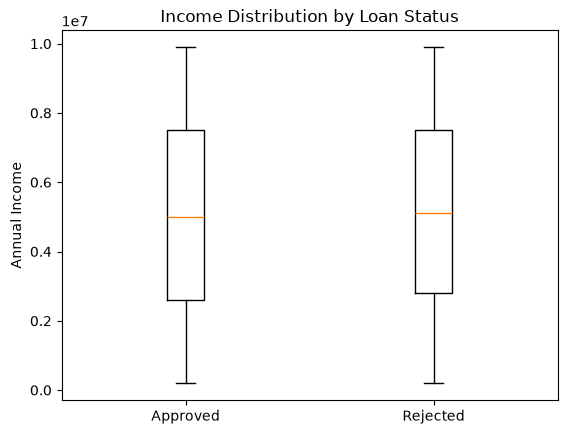

In [85]:
# C4 – Income vs Loan Approval

plt.boxplot(
    [
        df_eda[df_eda["loan_status"]=="Approved"]["income_annum"],
        df_eda[df_eda["loan_status"]=="Rejected"]["income_annum"]
    ],
    tick_labels=["Approved","Rejected"]
)

plt.title("Income Distribution by Loan Status")
plt.ylabel("Annual Income")

plt.show()

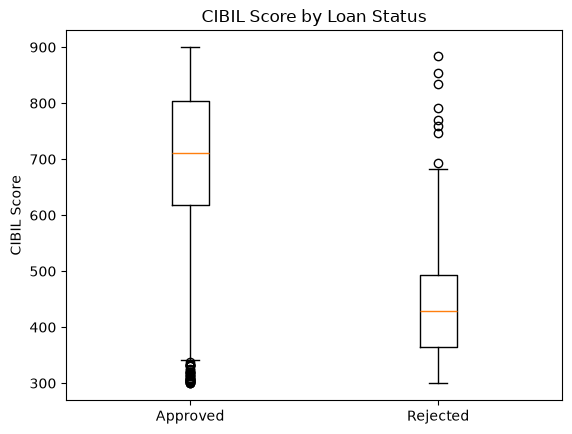

In [86]:
# C5 - CIBIL Score vs Loan Approval

plt.boxplot(
    [
        df_eda[df_eda["loan_status"]=="Approved"]["cibil_score"],
        df_eda[df_eda["loan_status"]=="Rejected"]["cibil_score"]
    ],
    tick_labels=["Approved","Rejected"]
)

plt.title("CIBIL Score by Loan Status")
plt.ylabel("CIBIL Score")

plt.show()

# Business Insights

## Key Findings

- The overall loan approval rate is **XX%**.
- Applicants with higher CIBIL scores have significantly higher approval rates.
- Education appears to have a limited/moderate influence on loan approval.
- Self-employment status shows a limited/moderate difference in approval rates.
- Applicants requesting moderate loan amounts account for the majority of approvals.
- Income alone is not a sufficient indicator of loan approval and should be interpreted alongside credit history and other financial variables.
- Loan term has some influence on approval distribution.